# Xây dựng mô hình từ giải thuật SVM trên dữ liệu bệnh tiểu đường. Dữ liệu lấy từ https://www.kaggle.com/code/tumpanjawat/diabetes-eda-random-forest-hp

# 1. Import thư viện & nạp dữ liệu

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

In [2]:
# Đọc dữ liệu từ file CSV
data = pd.read_csv("./data/diabetes_prediction_dataset.csv")

# Xem 5 dòng đầu tiên
print(data.head())

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  


In [3]:
# Thông tin tổng quan về kiểu dữ liệu và số null
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
None


In [4]:
# Thống kê mô tả cho các cột số
print(data.describe())

                 age  hypertension  heart_disease            bmi  \
count  100000.000000  100000.00000  100000.000000  100000.000000   
mean       41.885856       0.07485       0.039420      27.320767   
std        22.516840       0.26315       0.194593       6.636783   
min         0.080000       0.00000       0.000000      10.010000   
25%        24.000000       0.00000       0.000000      23.630000   
50%        43.000000       0.00000       0.000000      27.320000   
75%        60.000000       0.00000       0.000000      29.580000   
max        80.000000       1.00000       1.000000      95.690000   

         HbA1c_level  blood_glucose_level       diabetes  
count  100000.000000        100000.000000  100000.000000  
mean        5.527507           138.058060       0.085000  
std         1.070672            40.708136       0.278883  
min         3.500000            80.000000       0.000000  
25%         4.800000           100.000000       0.000000  
50%         5.800000           14

In [5]:
# Đếm số lượng giá trị thiếu ở mỗi cột
print(data.isna().sum())

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


# 2. Phân tích & loại bỏ features không liên quan

1. gender

Dạng phân loại (Male / Female / Other).

Có ý nghĩa thống kê với nguy cơ tiểu đường → Giữ lại.

2. age

Yếu tố quan trọng nhất → tuổi càng cao nguy cơ càng lớn → Giữ lại.

3. hypertension

Cao huyết áp liên quan mạnh đến tiểu đường type 2 → Giữ lại.

4. heart_disease

Bệnh tim thường đi kèm bệnh chuyển hóa → Giữ lại.

5. smoking_history

Hút thuốc ảnh hưởng đến hệ trao đổi chất → Giữ lại.

Nhưng dạng text → cần One-hot encode.

6. bmi

Chỉ số béo phì → yếu tố nguy cơ hàng đầu → Giữ lại.

7. HbA1c_level

Chỉ số đường huyết trung bình 3 tháng → cực kỳ quan trọng → Giữ lại.

8. blood_glucose_level

Đường huyết hiện tại → quan trọng nhất → Giữ lại.

9. diabetes

Biến mục tiêu

Tóm lại trong bộ dữ liệu này ta không cần loại feature nào.

# 3. Tiền xử lý dữ liệu

## 3.1 Xử lý giá trị trùng lắp

In [6]:
# Handle duplicates
duplicate_rows_data = data[data.duplicated()]
print("number of duplicate rows: ", duplicate_rows_data.shape)

number of duplicate rows:  (3854, 9)


In [7]:
data.drop_duplicates(inplace=True)
print(data.shape)

(96146, 9)


## 3.2 Mã hoá biến phân loại (gender, smoking_history)

In [8]:
# Các biến phân loại cần mã hóa
cat_cols = ["gender", "smoking_history"]

# One-hot encoding (drop_first=True để tránh đa cộng tuyến)
data_encoded = pd.get_dummies(data, columns=cat_cols, drop_first=True)

print(data_encoded.head())
print(data_encoded.columns)

    age  hypertension  heart_disease    bmi  HbA1c_level  blood_glucose_level  \
0  80.0             0              1  25.19          6.6                  140   
1  54.0             0              0  27.32          6.6                   80   
2  28.0             0              0  27.32          5.7                  158   
3  36.0             0              0  23.45          5.0                  155   
4  76.0             1              1  20.14          4.8                  155   

   diabetes  gender_Male  gender_Other  smoking_history_current  \
0         0        False         False                    False   
1         0        False         False                    False   
2         0         True         False                    False   
3         0        False         False                     True   
4         0         True         False                     True   

   smoking_history_ever  smoking_history_former  smoking_history_never  \
0                 False             

# 4. Chia tập train/test

In [9]:
# Biến đầu vào X và nhãn y
X = data_encoded.drop('diabetes', axis=1)
y = data_encoded['diabetes']

# Chia train/test (vd: 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Kích thước tập train:", X_train.shape)
print("Kích thước tập test :", X_test.shape)


Kích thước tập train: (76916, 13)
Kích thước tập test : (19230, 13)


# 5 Áp dụng mô hình SVM

chuẩn hóa dữ liệu

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
clf = SVC()
clf.fit(X_train, y_train)

train_acc = clf.score(X_train,y_train)
val_acc = clf.score(X_test,y_test)
print('Training accuracy: {}'.format(train_acc))
print('Validation accuracy: {}'.format(val_acc))

Training accuracy: 0.9453039679650528
Validation accuracy: 0.9462298491939678


# 6. Sử dụng GridSearchCV để tìm tham số tối ưu cho mô hình SVM

In [15]:
param_grid = {
    'C': [1, 10, 50],
    'gamma': ['scale',  0.01],
    'kernel': ['rbf']
}

grid = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_scaled, y_train)

print("Best parameters found:", grid.best_params_)
print("Best cross-validation score:", grid.best_score_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best parameters found: {'C': 50, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validation score: 0.9644157187973198


Best params: {'C': 50, 'gamma': 'scale', 'kernel': 'rbf'}
Test accuracy: 0.9656266250650026

Classification report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98     17534
           1       0.96      0.63      0.76      1696

    accuracy                           0.97     19230
   macro avg       0.96      0.82      0.87     19230
weighted avg       0.97      0.97      0.96     19230


Confusion matrix:
 [[17494    40]
 [  621  1075]]
AUC: 0.9415356229729411


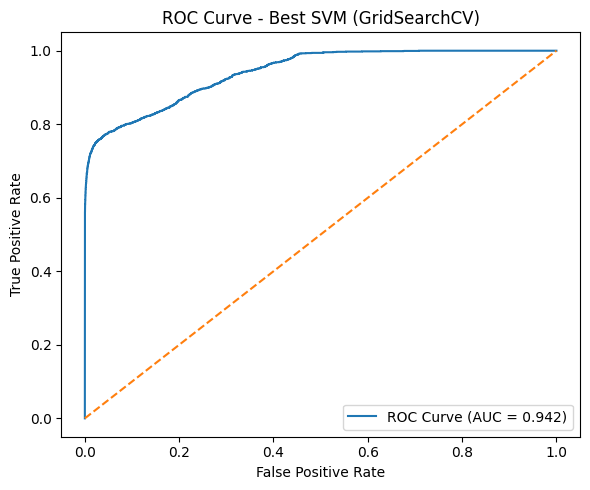

In [17]:
# Lấy bộ tham số tối ưu từ GridSearch
best_params = grid.best_params_
print("Best params:", best_params)

# Tạo lại mô hình SVM với probability=True để dùng predict_proba
best_svm = SVC(
    **best_params,        # gồm C, gamma, kernel (nếu có trong param_grid)
    probability=True      # thêm dòng này để dùng được predict_proba
)

# Huấn luyện lại trên tập train đã scale
best_svm.fit(X_train_scaled, y_train)

# ---------------------------
#  Đánh giá trên tập test
# ---------------------------
y_pred = best_svm.predict(X_test_scaled)

print("Test accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))

# ---------------------------
#  ROC Curve + AUC
# ---------------------------
# Xác suất dự đoán lớp 1 (bị tiểu đường)
y_prob = best_svm.predict_proba(X_test_scaled)[:, 1]

# Tính FPR, TPR cho các ngưỡng threshold khác nhau
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_value = roc_auc_score(y_test, y_prob)
print("AUC:", auc_value)

# Vẽ ROC
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_value:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")  # đường chéo random
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Best SVM (GridSearchCV)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Kết thúc